# Clustering the result of a MCA with DBSCAN

NOT yet finished, do not use !

#### Documentation 

[Comparing clustering algorithms](https://hdbscan.readthedocs.io/en/latest/comparing_clustering_algorithms.html) 


In [1]:
import numpy as np
import pandas as pd

import sqlite3 as sql

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import seaborn as sns

import networkx as nx
import itertools

import scipy.cluster.hierarchy as sch
from scipy.cluster.hierarchy import fcluster
from scipy.spatial.distance import cdist

import fanalysis.ca as fa 

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.neighbors import NearestNeighbors

from prince import MCA


In [2]:
### this library allows to execute SQL queries on dataframes
# and even joins
!pip install duckdb

Do not use pip without activating a virtual environment first!
Otherwise, you might break your default Python environment and not be able to start Jupyter again.
Check the Documentation on how to deal with virtual environments:
🗀 / Documentation / 10_Envs_and_kernels.ipynb


In [3]:
import sys
!{sys.executable} -m pip install duckdb


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /home/my_venvs/data_analysis/bin/python3 -m pip install --upgrade pip


In [4]:
import duckdb
print(duckdb.__version__)

1.5.4


In [5]:
### Importer un module de fonctions crées ad hoc
##  ATTENTION : le fichier 'sparql_functions.py' doit se trouver 
#   dans un dossier qui se situe dans le chemin ('path') de recherche
#   vu par le présent carnet Jupyter afin que
#   l'importation fonctionne correctement

import sys
from importlib import reload


# Add parent directory to the path
sys.path.insert(0, '..')

### If you want to add the parent-parent directory,
sys.path.insert(0, '../..')



In [6]:
## these are local libraries of functions 
import bivariate_library as bl
import correspondence_analysis_library as cal
import cluster_functions as cf


In [7]:
### Use this command to reload the functions 
# if you modify them
print(reload(cf))


<module 'cluster_functions' from '/home/my_notebooks/Jupypter_notebooks/cluster_functions.py'>


In [8]:
import warnings
warnings.filterwarnings('ignore')


## Create a dataframe with the data to be analysed

In this notebook, we use the data produced in the [multiple correspondence analysis (MCA) notebook ](da5_MCA.ipynb), which was prepared and exported into this file [this file](da_data/da5-MCA-clusters.csv) after the sparse data was aggregated.




In [9]:
file_address='../da5_data/da5-MCA-clusters.csv'
df_pm = pd.read_csv(file_address)
df_pm.head(3)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,...,CNTR_NAME,NAME_ENGL,ISO3_CODE,coded_country,activityYear,periodsActivity,pk_person_features,occupation_main,occupation_sec1,education_place
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,...,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,...,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,other_uni
2,http://www.wikidata.org/entity/Q567735,Charles Robert Cockerell,1788,male,London,POINT (-0.1275 51.507222),http://www.wikidata.org/entity/Q84,1781-1790,24,Northern Europe,...,United Kingdom,United Kingdom,GBR,United Kingdom,1833.0,1826-1850,13896,archaeologist,anthropologist,other_uni


In [10]:
print(df_pm.columns.to_list())

['person_uri', 'labelPer', 'birthYear', 'gender', 'labelPlace', 'geometry', 'uriPlace', 'periods', 'FID', 'REGION', 'CNTR_ID', 'CNTR_NAME', 'NAME_ENGL', 'ISO3_CODE', 'coded_country', 'activityYear', 'periodsActivity', 'pk_person_features', 'occupation_main', 'occupation_sec1', 'education_place']


In [11]:
### Rename columns to have shorter labels
df_pm.columns=['person_uri',
 'labelPer',
 'birthYear',
 'gender',
 'labelPlace',
 'geometry',
 'uriPlace',
 'periods',
 'FID',
 'REGION',
 'CNTR_ID',
 'CNTR_NAME',
 'NAME_ENGL',
 'ISO3_CODE',
 'country',
 'activityYear',
 'per_activ',
 'pk_person_features',
 'occup_main',
 'occup_sec',
 'edpl']

In [12]:
### Inspect the dataframe and 
# notably if there are missing values
df_pm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1713 entries, 0 to 1712
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   person_uri          1713 non-null   object 
 1   labelPer            1713 non-null   object 
 2   birthYear           1713 non-null   int64  
 3   gender              1713 non-null   object 
 4   labelPlace          1713 non-null   object 
 5   geometry            1713 non-null   object 
 6   uriPlace            1713 non-null   object 
 7   periods             1713 non-null   object 
 8   FID                 1713 non-null   int64  
 9   REGION              1713 non-null   object 
 10  CNTR_ID             1713 non-null   object 
 11  CNTR_NAME           1713 non-null   object 
 12  NAME_ENGL           1713 non-null   object 
 13  ISO3_CODE           1713 non-null   object 
 14  country             1713 non-null   object 
 15  activityYear        1713 non-null   float64
 16  per_ac

In [13]:
### change display options for jupyter notebooks
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
# Reset to default settings if needed later
# pd.reset_option('display.max_columns

## Factor analysis (MCA)

We only consider for MCA the coded features of persons, transformed into qualitative categories 

We don't use the periods for defining profiles, our research question is about inspecting the correlation between profiles and periods, and identify specific profiles for specific periods

In [14]:
### Define the variables that will be used for analysing the population profiles
df_actives = df_pm[['gender', 'country', 'occup_sec', 'edpl']].copy(deep=True)
print(df_actives.columns)
df_actives.head(2)

Index(['gender', 'country', 'occup_sec', 'edpl'], dtype='object')


,gender,country,occup_sec,edpl
0,male,Central Europe,other,University of Göttingen
1,male,United States Can.,historian,other_uni


In [15]:
### We add here also the main occupation, hoping it helps to get more structure
df_actives = df_pm[['gender', 'country', 'occup_main', 'occup_sec', 'edpl']].copy(deep=True)
print(df_actives.columns)
df_actives.head(2)

Index(['gender', 'country', 'occup_main', 'occup_sec', 'edpl'], dtype='object')


,gender,country,occup_main,occup_sec,edpl
0,male,Central Europe,archaeologist,other,University of Göttingen
1,male,United States Can.,archaeologist,historian,other_uni


### Process in two steps

First fit, then transform.

The mca variable will be used to project illustrative variables, in our case periods of activity

In [16]:
### MCA with benzecri correction: whole intertia in 5 axis
# Equivalent to fit_transform but in to steps
mca = MCA(n_components=10, n_iter=10, correction='benzecri',random_state=42)
mca.fit(df_actives)

,n_components,10
,n_iter,10
,copy,True
,check_input,True
,random_state,42
,engine,'sklearn'
,one_hot,True
,one_hot_prefix_sep,'__'
,one_hot_columns_to_drop,None
,correction,'benzecri'


In [17]:
### Benzecri correction and approximation allows to summarize 
# the most relevant aspects of the variance in five axes (in this case)
mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.042,24.92%,24.92%
1,0.037,21.87%,46.79%
2,0.030,17.78%,64.57%
3,0.017,10.15%,74.72%
4,0.016,9.57%,84.29%
5,0.015,8.95%,93.24%
6,0.006,3.64%,96.88%
7,0.003,1.63%,98.51%
8,0.001,0.78%,99.29%


In [18]:
### Coordinates of categories, i.e. columns in the complete disjoint table
print(len(mca.column_coordinates(df_actives)))
dfcc = mca.column_coordinates(df_actives)
dfcc.head()

42


,0,1,2,3,4,5,6,7,8,9
gender__female,-0.852850,-0.253187,0.881201,-0.353804,0.005383,-0.076687,-0.420791,1.401184,-0.264970,0.954592
gender__male,0.072376,0.021486,-0.074782,0.030025,-0.000457,0.006508,0.035710,-0.118910,0.022486,-0.081010
country__Austria Hungary,2.510988,2.030733,1.914021,0.394769,-0.438090,-0.713663,0.368224,-0.093956,-0.945214,-0.367562
country__Baltic States Fin. Belar.,-0.123756,0.408156,-0.211619,-0.089342,0.077644,0.962270,-0.561940,-0.516130,1.806353,0.421764
country__Belgium Netherl.,-0.175961,-0.065774,-0.115989,0.261902,0.338493,0.467483,-0.819959,0.724737,-0.568835,0.558200


In [19]:
### Coordinates of persons (rows)
# The same result as using the method 'fit_transform'
print(len(mca.row_coordinates(df_actives)))
dfrc = mca.row_coordinates(df_actives)
dfrc.head()

1713


,0,1,2,3,4,5,6,7,8,9
0,0.736028,-0.107151,-0.218946,-0.073330,-0.051257,-0.050066,-0.024816,0.927168,1.386919,-0.503656
1,-0.500813,-0.036686,0.306928,-0.057696,-0.356715,0.075477,0.273982,-0.326621,0.358300,0.311872
2,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287
3,-0.553440,-0.154024,0.138679,3.597661,2.642227,-0.411869,0.178344,-0.717978,0.094301,-0.285042
4,-0.443578,0.087769,-0.169606,0.006814,-0.298825,-0.428046,-0.048894,-0.083687,-0.085828,-0.439261


In [20]:
### Equivalent to fit transform in one step
X_mca=mca.transform(df_actives)
X_mca.head()

,0,1,2,3,4,5,6,7,8,9
0,0.736028,-0.107151,-0.218946,-0.073330,-0.051257,-0.050066,-0.024816,0.927168,1.386919,-0.503656
1,-0.500813,-0.036686,0.306928,-0.057696,-0.356715,0.075477,0.273982,-0.326621,0.358300,0.311872
2,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287
3,-0.553440,-0.154024,0.138679,3.597661,2.642227,-0.411869,0.178344,-0.717978,0.094301,-0.285042
4,-0.443578,0.087769,-0.169606,0.006814,-0.298825,-0.428046,-0.048894,-0.083687,-0.085828,-0.439261


### Prepare first two axis

In [21]:
ax1=mca.eigenvalues_summary.iloc[0, 1]
ax2=mca.eigenvalues_summary.iloc[1, 1]

### Calculate position of illustrative variable 'per_activ'

We don't use the periods for defining profiles, our research question is about inspecting the correlation between profiles and periods, and identify specific profiles for specific periods

In [22]:
df_illustrative = df_pm[['per_activ']].copy(deep=True)
# df_illustrative.head(2)

In [23]:
df_per_activ=pd.DataFrame(df_pm.groupby('per_activ').size())
# df_per_activ.index=df_per_activ.index.map(lambda x: f'per_activ__{x}')
df_per_activ.columns=['number']
df_per_activ

,number
per_activ,
1826-1850,84
1851-1875,174
1876-1900,287
1901-1925,412
1926-1950,502
1951-1975,254


In [24]:
### This script situates the illustrative variable 'per_activ'
# at the mean position in the geometric space using the coordinates 
# of all the individuals

row_coords = mca.row_coordinates(df_actives)

# 3. Select the single illustrative variable column
illus_var = df_illustrative['per_activ'] # Replace with actual column name

# 4. Calculate position for each category in that variable
supp_positions = {}

for category in illus_var.dropna().unique():
    # Find indices of individuals who have this category
    mask = illus_var == category
    
    # Calculate the barycenter (mean) of their row coordinates
    # This is the position of the supplementary category
    centroid = row_coords[mask].mean(axis=0)
    
    supp_positions[category] = centroid.values

# 5. Convert to DataFrame for easy use/plotting
df_per_activ_pos = pd.DataFrame(
    supp_positions, 
    index=[i for i in range(row_coords.shape[1])]
).T  # Transpose so rows are categories, columns are dimensions

df_per_activ_pos.head(2)

,0,1,2,3,4,5,6,7,8,9
1826-1850,0.034295,-0.026798,-0.171566,0.073699,0.081694,-0.032894,-0.077274,-0.049686,0.060497,-0.084250
1851-1875,-0.027175,0.017370,-0.185893,0.078103,-0.004464,0.086721,-0.018534,-0.001295,0.015948,-0.092894


In [25]:
### We add the label and the number of individuals to the mean position
df_per_activ=df_per_activ.join(df_per_activ_pos)
df_per_activ

,number,0,1,2,3,4,5,6,7,8,9
per_activ,,,,,,,,,,,
1826-1850,84,0.034295,-0.026798,-0.171566,0.073699,0.081694,-0.032894,-0.077274,-0.049686,0.060497,-0.084250
1851-1875,174,-0.027175,0.017370,-0.185893,0.078103,-0.004464,0.086721,-0.018534,-0.001295,0.015948,-0.092894
1876-1900,287,0.055898,-0.009300,-0.086274,0.026249,-0.014129,0.039685,-0.012631,-0.053936,0.032343,-0.110849
1901-1925,412,0.044338,-0.037825,-0.014630,0.045879,-0.068359,-0.061525,-0.015617,-0.015111,-0.011400,-0.014353
1926-1950,502,-0.026051,0.034606,0.099210,-0.056398,0.076679,-0.006774,0.035995,0.024501,0.010757,0.073922
1951-1975,254,-0.076316,0.000430,0.109220,-0.070490,-0.048659,0.019814,0.006716,0.054350,-0.070246,0.093933


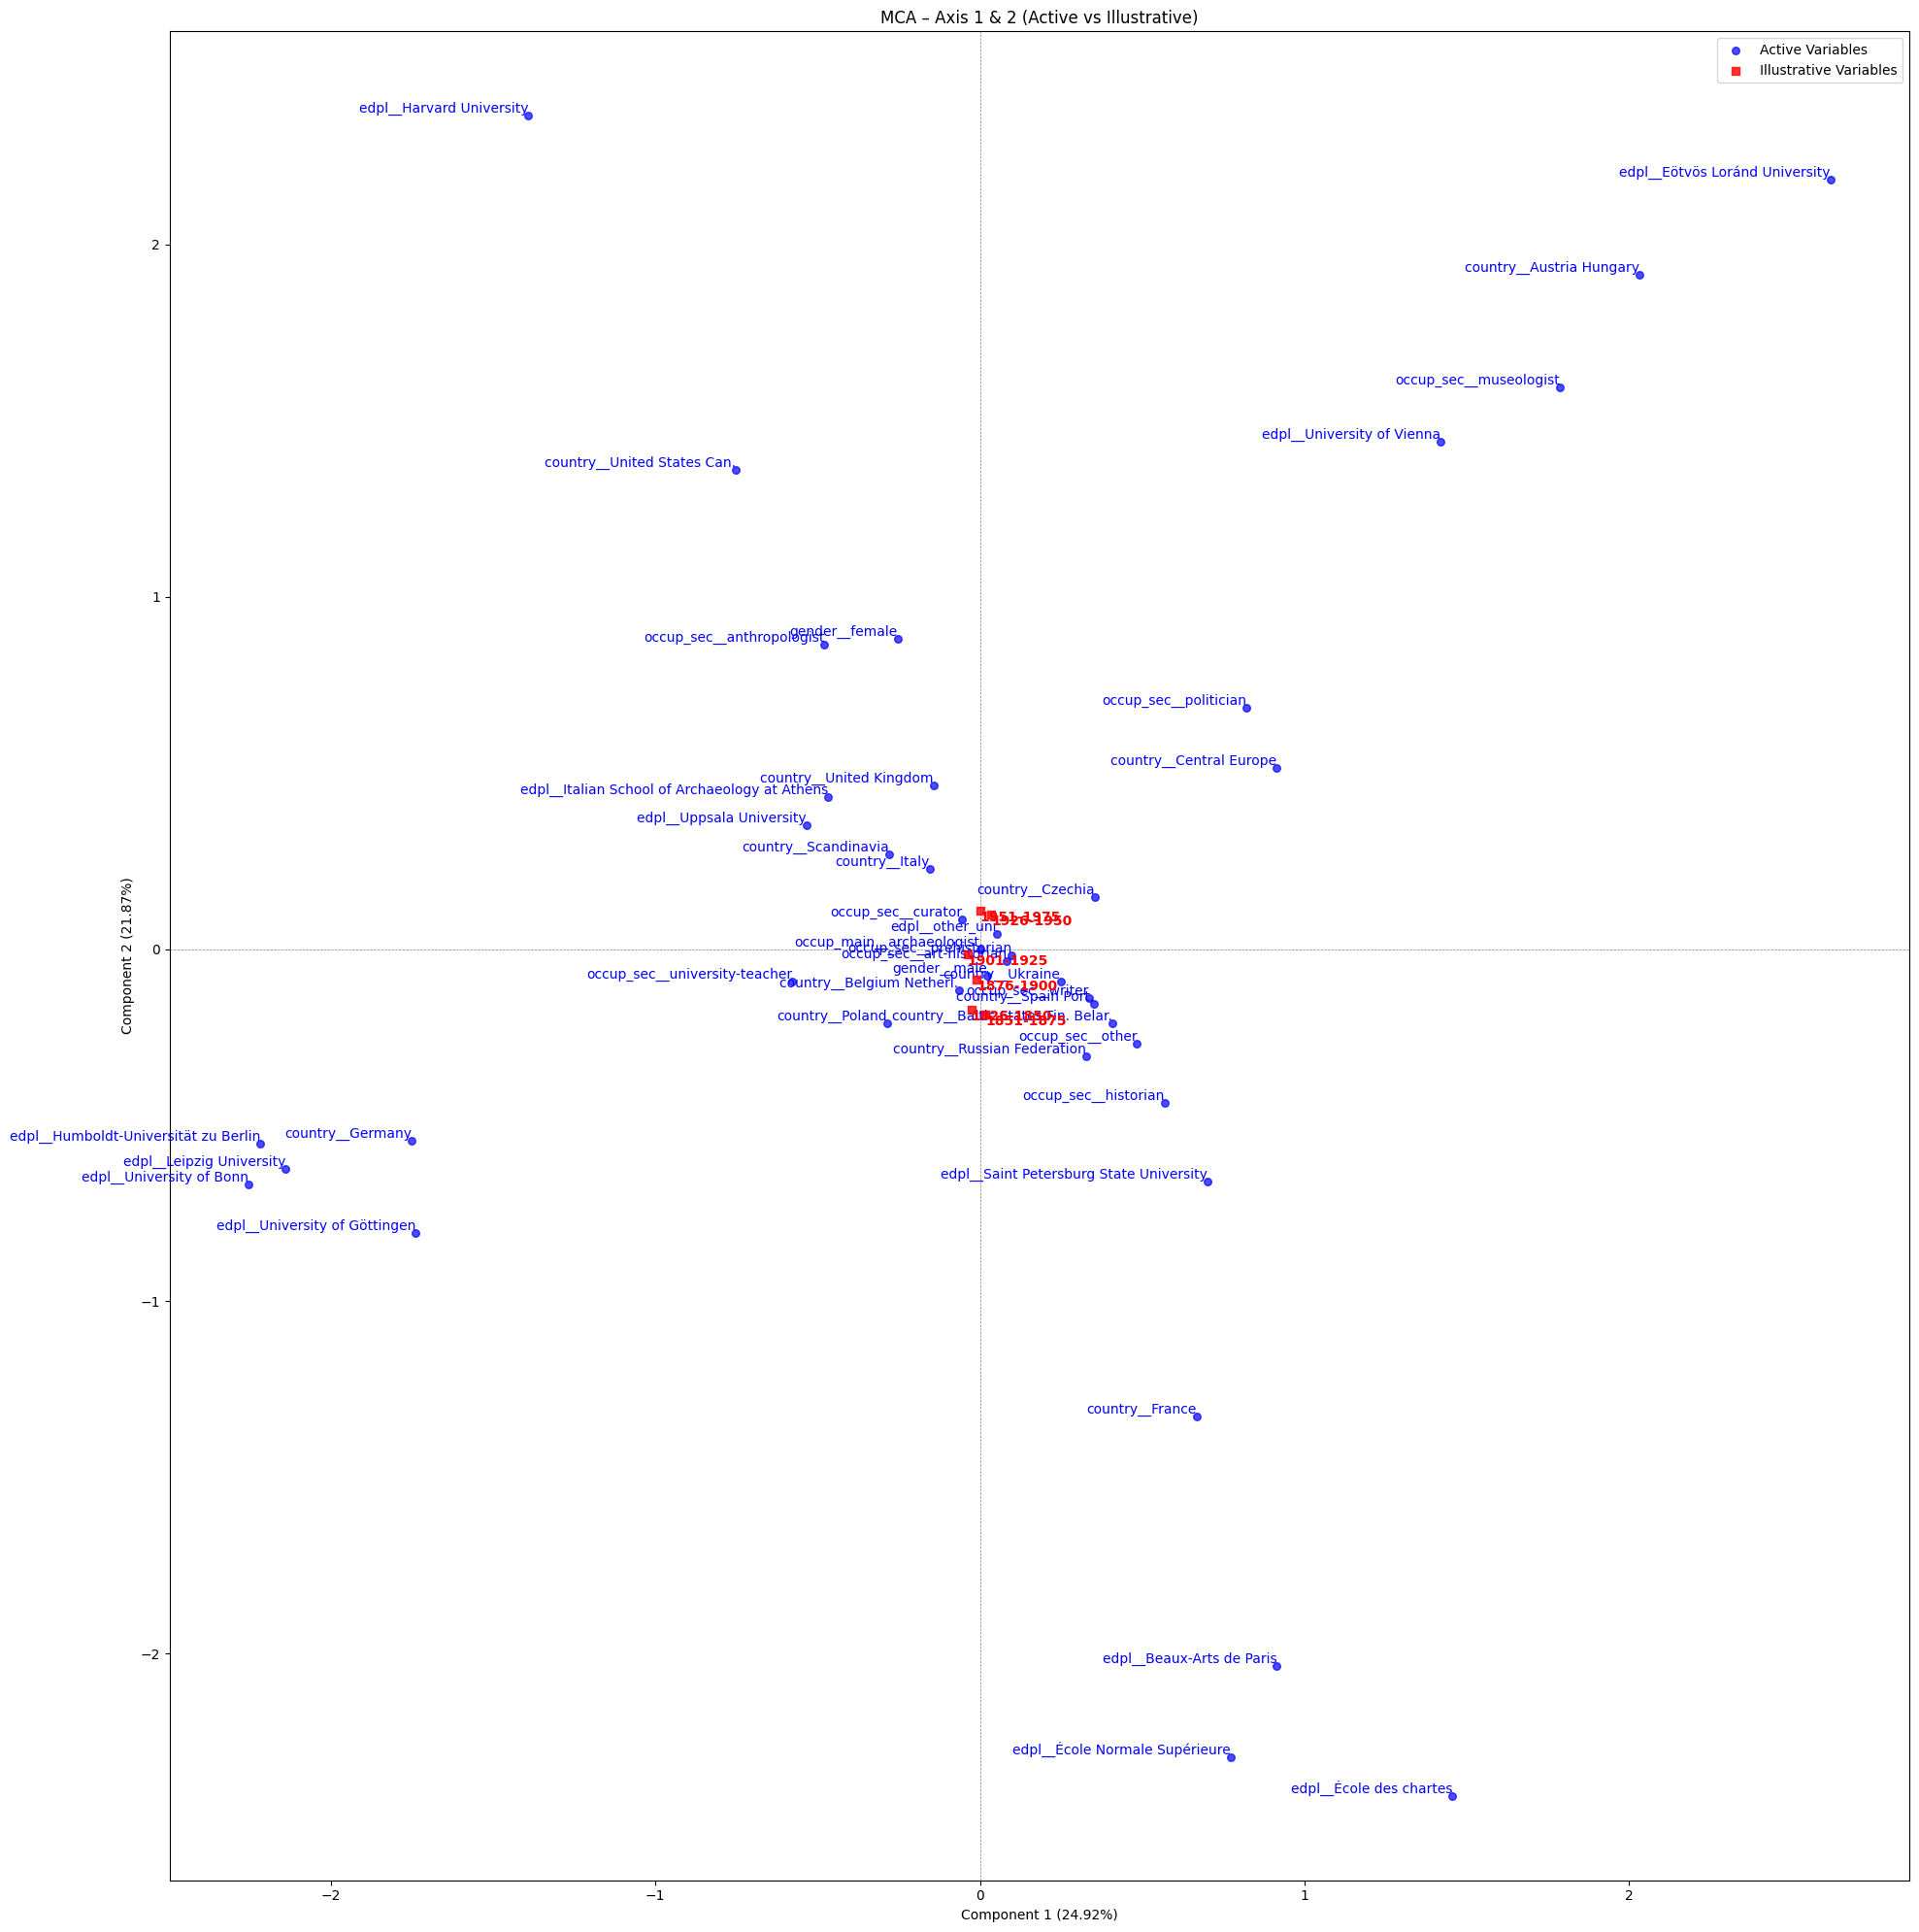

In [26]:
### dimensions
d1=1 # 0
d2=2 # 1

# Create the plot
fig, ax = plt.subplots(figsize=(20, 20))

# Plot Active Variables (Blue/Grey default)
ax.scatter(dfcc[d1], dfcc[d2], s=30, alpha=0.7, c='blue', label='Active Variables', zorder=3)

# Label Active Variables
for label, x, y in zip(dfcc.index, dfcc[d1], dfcc[d2]):
    ax.annotate(label, (x, y), fontsize=10, ha='right', va='bottom', color='blue')

# Plot Illustrative Variables (Red)
if not df_per_activ.empty:
    ax.scatter(df_per_activ[d1], df_per_activ[d2], 
               s=30, alpha=0.8, c='red', marker='s', label='Illustrative Variables', zorder=4)
    
    # Label Illustrative Variables (optional: adjust font size/color to distinguish)
    for label, x, y in zip(df_per_activ.index, df_per_activ[d1], df_per_activ[d2]):
        ax.annotate(label, (x, y), fontsize=10, ha='left', va='top', color='red', fontweight='bold')

# Add reference lines
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

# Set labels and title
ax.set_xlabel(f"Component 1 ({ax1})") # Formatting percentage if applicable
ax.set_ylabel(f"Component 2 ({ax2})")
ax.set_title("MCA – Axis 1 & 2 (Active vs Illustrative)")

# Add legend to distinguish groups
ax.legend(loc='best')

# Save the figure
img_address='../images/mca_prince_with_periods.png'
plt.savefig(img_address, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

## DBSCAN


Cluster with the DBSCAN method

In [27]:

# Optional: Scale coordinates (often helps DBSCAN)
scaler = StandardScaler()
mca_scaled = scaler.fit_transform(X_mca)
print(mca_scaled[:2])


[[ 1.22000891 -0.18019302 -0.37631859 -0.13286094 -0.09333115 -0.09167183
  -0.04841762  1.88468733  2.89760631 -1.05558093]
 [-0.83012566 -0.06169455  0.52754038 -0.10453512 -0.64952127  0.13820008
   0.53455895 -0.66393482  0.74857346  0.65363163]]


### Prepare hyperparameters

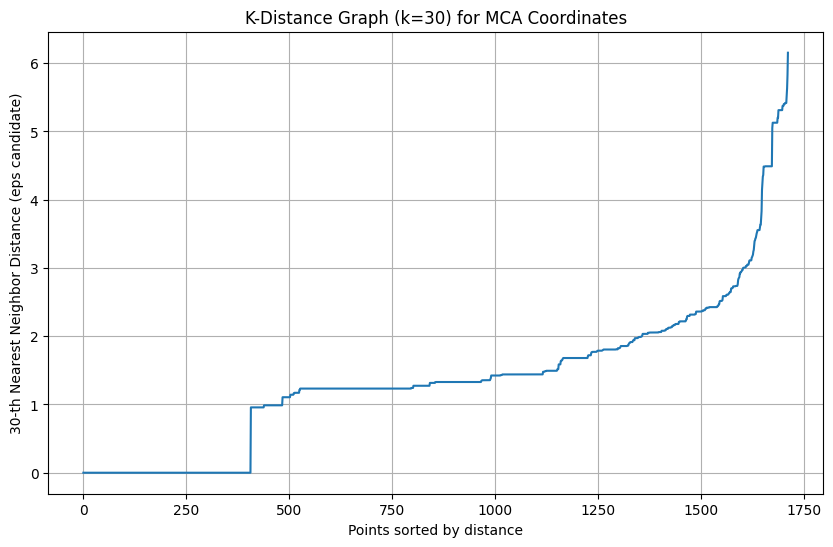

In [28]:


# 2. Define min_samples first
# Rule of thumb: min_samples >= Number of Dimensions + 1
# For MCA, if you kept 5 dimensions, try min_samples = 6 or higher.
# For noisy data, higher is better (e.g., 10-20).
# We take 20, minimum number of individuals in clusters
min_samples_val = 30 

# 3. Fit Nearest Neighbors
# We look for the distance to the (min_samples_val)-th nearest neighbor
nbrs = NearestNeighbors(n_neighbors=min_samples_val).fit(mca_scaled)

# 4. Calculate Distances
distances, indices = nbrs.kneighbors(mca_scaled)

# 5. Extract the k-th distance for each point (last column because sorted)
k_distances = distances[:, -1]

# 6. Sort distances in ascending order
k_distances_sorted = np.sort(k_distances)

# 7. Plot the K-Distance Graph
plt.figure(figsize=(10, 6))
plt.plot(k_distances_sorted)
plt.title(f'K-Distance Graph (k={min_samples_val}) for MCA Coordinates')
plt.xlabel('Points sorted by distance')
plt.ylabel(f'{min_samples_val}-th Nearest Neighbor Distance (eps candidate)')
plt.grid(True)
plt.show()

### Apply DBSCAN

In [29]:
# Candidate eps from the graph
eps_candidate = 0.8 # 0.9
min_samples_val = 50

db = DBSCAN(eps=eps_candidate, min_samples=min_samples_val).fit(mca_scaled)
labels = db.labels_

# Filter out noise points (-1) for scoring
non_noise_mask = labels != -1
if len(np.unique(labels[non_noise_mask])) > 1:
    score = silhouette_score(mca_scaled[non_noise_mask], labels[non_noise_mask])
    print(f"Silhouette Score (eps={eps_candidate}): {score:.3f}")
else:
    print("Not enough clusters formed to calculate Silhouette Score.")

Silhouette Score (eps=0.8): 1.000


In [30]:
# Apply DBSCAN
# eps and min_samples need tuning based on your specific data distribution
# elbow at three
db = DBSCAN(eps=eps_candidate, min_samples=min_samples_val, metric='euclidean')
clusters = db.fit_predict(mca_scaled)

# Add cluster label (number) to original dataframe
df_actives['cluster'] = clusters
df_pm['cluster'] = clusters

cluster_counts=df_actives['cluster'].value_counts()
print(len(cluster_counts))

3


In [31]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    print(cluster_counts)

cluster
-1    1589
 0      67
 1      57
Name: count, dtype: int64


In [32]:

# ==========================================
# 4. CALCULATE MEDOIDS & EXTRACT LABELS
# ==========================================
def get_cluster_summary(df_original, mca_coords, labels):
    """
    Returns a DataFrame with:
    - Cluster ID
    - Size of cluster
    - Medoid Index (original row index)
    - All original categorical columns of the Medoid
    """
    summary_data = []
    
    unique_labels = set(labels)
    # Remove noise (-1) if you don't want it in the summary
    # If you want to analyze noise, keep it but note it has no true medoid
    ## cluster_ids = sorted([l for l in unique_labels if l != -1])
    ### keep the medoid
    cluster_ids = sorted([l for l in unique_labels])
    
    for cid in cluster_ids:
        # Get indices of points in this cluster
        cluster_mask = (labels == cid)
        cluster_indices = np.where(cluster_mask)[0]
        
        if len(cluster_indices) == 0:
            continue
            
        # Get MCA coordinates for this cluster
        cluster_coords = mca_coords.iloc[cluster_indices]
        
        # Calculate pairwise distances
        dist_matrix = pairwise_distances(cluster_coords)
        
        # Find medoid: point with minimum sum of distances to others
        sum_dists = dist_matrix.sum(axis=1)
        medoid_local_idx = np.argmin(sum_dists)
        medoid_original_idx = cluster_indices[medoid_local_idx]
        
        # Extract the original categorical labels for the medoid
        medoid_row = df_original.iloc[medoid_original_idx]
        
        # Build summary row
        summary_row = {
            'Cluster_ID': cid,
            'Cluster_Size': len(cluster_indices),
            'Medoid_Original_Index': medoid_original_idx
        }
        
        # Add all original categorical columns (excluding 'Cluster_ID' if already added)
        for col in df_original.columns:
            if col != 'Cluster_ID' and  col != 'cluster':
                # summary_row[f'Medoid_{col}'] = medoid_row[col]
                summary_row[f'{col}'] = medoid_row[col]
                
        summary_data.append(summary_row)
    
    return pd.DataFrame(summary_data)


In [33]:
### Generate the summary table with original labels and medoids
# we use the function defined above
cluster_summary = get_cluster_summary(df_actives, X_mca, clusters)

In [34]:
cluster_summary.sort_values('Cluster_Size',ascending=False).head()

,Cluster_ID,Cluster_Size,Medoid_Original_Index,gender,country,occup_main,occup_sec,edpl
0,-1,1589,663,male,Ukraine,archaeologist,university-teacher,other_uni
1,0,67,2,male,United Kingdom,archaeologist,anthropologist,other_uni
2,1,57,14,male,Germany,archaeologist,university-teacher,other_uni


In [35]:
print(cluster_summary.columns.to_list())

['Cluster_ID', 'Cluster_Size', 'Medoid_Original_Index', 'gender', 'country', 'occup_main', 'occup_sec', 'edpl']


In [36]:
### rename columns
cluster_summary.columns=['cluster',
 'Cluster_Size',
 'Original_Index',
 'gender',
 'country',
 'occup_main',
 'occup',
 'edpl']
cluster_summary.head(2)

,cluster,Cluster_Size,Original_Index,gender,country,occup_main,occup,edpl
0,-1,1589,663,male,Ukraine,archaeologist,university-teacher,other_uni
1,0,67,2,male,United Kingdom,archaeologist,anthropologist,other_uni


In [37]:
dfrc.head(2)

,0,1,2,3,4,5,6,7,8,9
0,0.736028,-0.107151,-0.218946,-0.073330,-0.051257,-0.050066,-0.024816,0.927168,1.386919,-0.503656
1,-0.500813,-0.036686,0.306928,-0.057696,-0.356715,0.075477,0.273982,-0.326621,0.358300,0.311872


In [38]:
### coordinates of medoids as cluster profiles
cluster_profiles=cluster_summary[['cluster',
 'Cluster_Size',
 'Original_Index',
 'gender',
 'country',
 'occup',
 'edpl']].merge(dfrc, left_on='Original_Index', right_index=True)

In [39]:
cluster_profiles.head(2)

,cluster,Cluster_Size,Original_Index,gender,country,occup,edpl,0,1,2,3,4,5,6,7,8,9
0,-1,1589,663,male,Ukraine,university-teacher,other_uni,0.093515,-0.086417,-0.074434,-0.038217,0.041087,0.372291,0.000615,-0.138769,-0.029162,0.367005
1,0,67,2,male,United Kingdom,anthropologist,other_uni,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287


In [40]:
### Create a label with the mode categories
cluster_profiles['label'] = cluster_profiles.apply(
    lambda x: str(x.name) + "_" + "_".join(x[['gender', 'country', 'occup', 'edpl']].astype(str)), 
    axis=1
)
cluster_profiles.head(1)

,cluster,Cluster_Size,Original_Index,gender,country,occup,edpl,0,1,2,3,4,5,6,7,8,9,label
0,-1,1589,663,male,Ukraine,university-teacher,other_uni,0.093515,-0.086417,-0.074434,-0.038217,0.041087,0.372291,0.000615,-0.138769,-0.029162,0.367005,0_male_Ukraine_university-teacher_other_uni


In [41]:
### Create a label with the mode categories

cluster_profiles[cluster_profiles['cluster']==-1]

,cluster,Cluster_Size,Original_Index,gender,country,occup,edpl,0,1,2,3,4,5,6,7,8,9,label
0,-1,1589,663,male,Ukraine,university-teacher,other_uni,0.093515,-0.086417,-0.074434,-0.038217,0.041087,0.372291,0.000615,-0.138769,-0.029162,0.367005,0_male_Ukraine_university-teacher_other_uni


In [42]:
### Inspect the already created illustrative variable 'per_act'
df_per_activ

,number,0,1,2,3,4,5,6,7,8,9
per_activ,,,,,,,,,,,
1826-1850,84,0.034295,-0.026798,-0.171566,0.073699,0.081694,-0.032894,-0.077274,-0.049686,0.060497,-0.084250
1851-1875,174,-0.027175,0.017370,-0.185893,0.078103,-0.004464,0.086721,-0.018534,-0.001295,0.015948,-0.092894
1876-1900,287,0.055898,-0.009300,-0.086274,0.026249,-0.014129,0.039685,-0.012631,-0.053936,0.032343,-0.110849
1901-1925,412,0.044338,-0.037825,-0.014630,0.045879,-0.068359,-0.061525,-0.015617,-0.015111,-0.011400,-0.014353
1926-1950,502,-0.026051,0.034606,0.099210,-0.056398,0.076679,-0.006774,0.035995,0.024501,0.010757,0.073922
1951-1975,254,-0.076316,0.000430,0.109220,-0.070490,-0.048659,0.019814,0.006716,0.054350,-0.070246,0.093933


### Plot the cluster profiles

In [43]:
### Get the inertia proportion for the first two axis
ax1=mca.eigenvalues_summary.iloc[0, 1]
ax2=mca.eigenvalues_summary.iloc[1, 1]

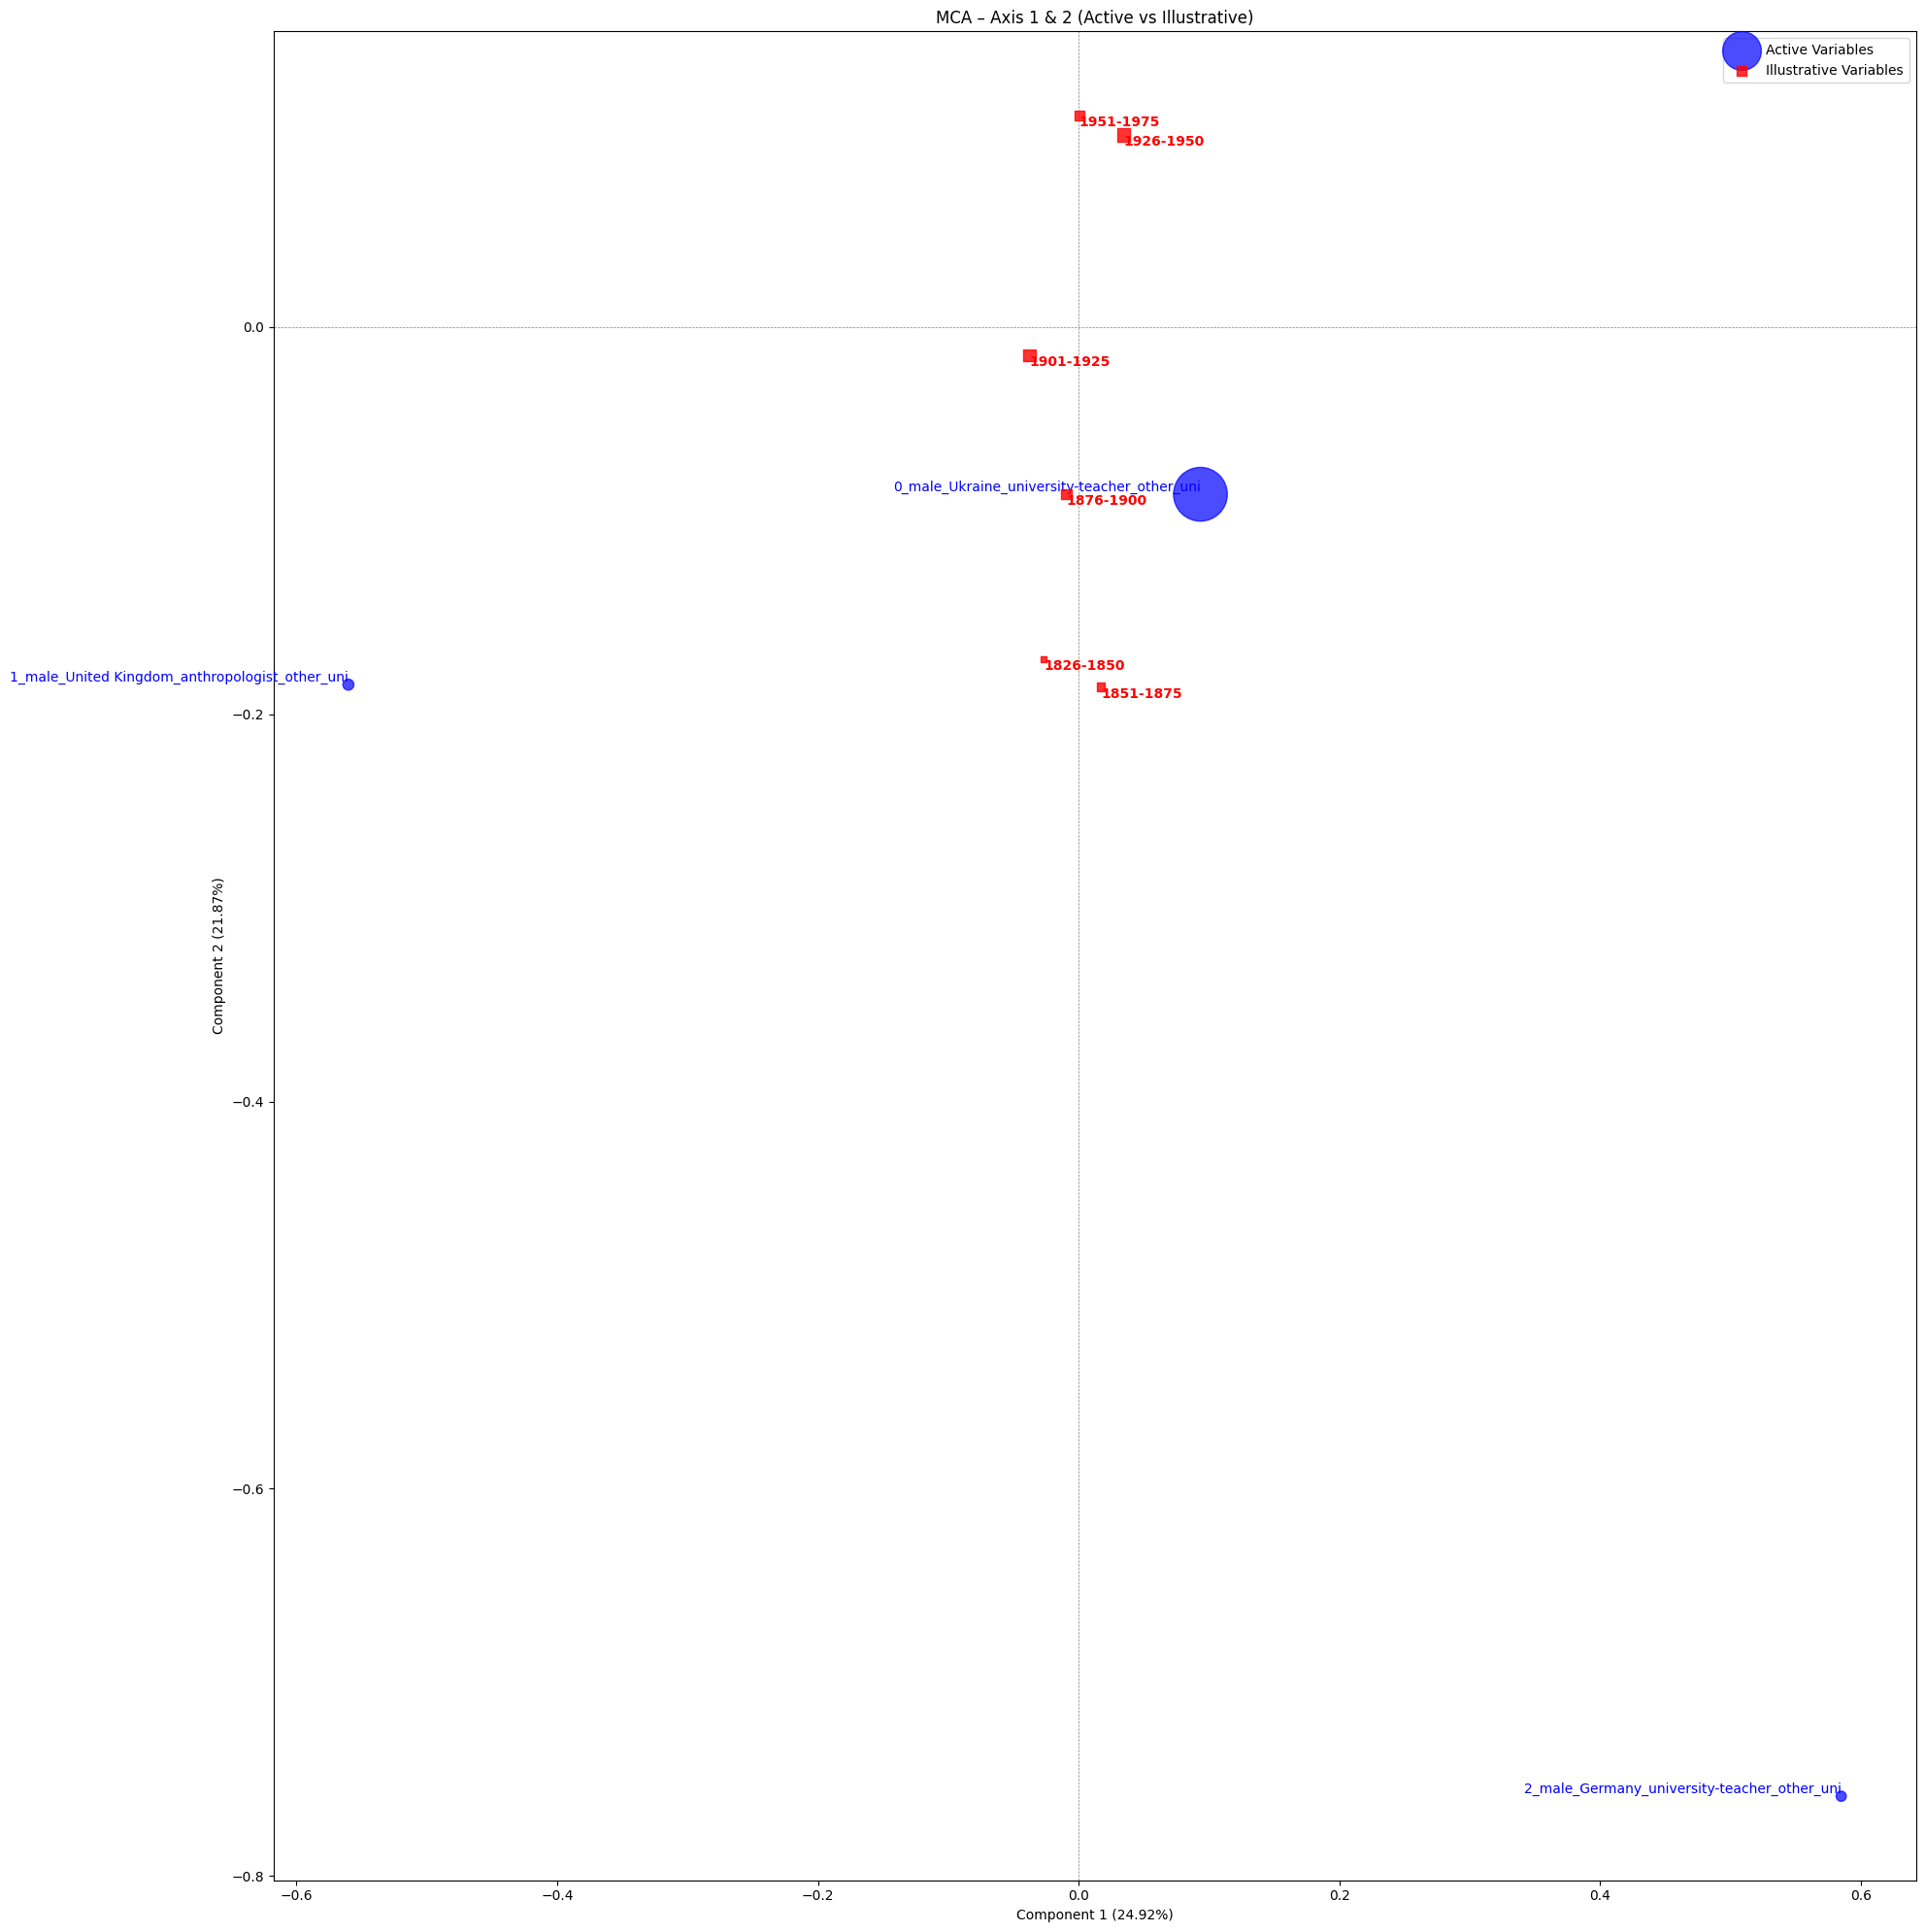

In [44]:

# Get coordinates for illustrative variables
# Note: Ensure 'df_illustrative' contains the column names of your illustrative variables
df_illust_coords = mca.column_coordinates(df_illustrative)

# Create the plot
fig, ax = plt.subplots(figsize=(20, 20))

# Plot Active Variables (Blue/Grey default)
ax.scatter(cluster_profiles[0], cluster_profiles[1], 
           s=cluster_profiles['Cluster_Size'], alpha=0.7, c='blue', label='Active Variables', zorder=3)

# Label Active Variables
for label, x, y in zip(cluster_profiles.label, cluster_profiles[0], cluster_profiles[1]):
    ax.annotate(label, (x, y), fontsize=10, ha='right', va='bottom', color='blue')

# Plot Illustrative Variables (Red)
if not df_per_activ.empty:
    ax.scatter(df_per_activ[1], df_per_activ[2], 
               s=df_per_activ['number']/5, alpha=0.8, c='red', marker='s', label='Illustrative Variables', zorder=4)
    
    # Label Illustrative Variables (optional: adjust font size/color to distinguish)
    for label, x, y in zip(df_per_activ.index, df_per_activ[1], df_per_activ[2]):
        ax.annotate(label, (x, y), fontsize=10, ha='left', va='top', color='red', fontweight='bold')

# Add reference lines
ax.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax.axvline(0, color='grey', linewidth=0.5, linestyle='--')

# Set labels and title
ax.set_xlabel(f"Component 1 ({ax1})") # Formatting percentage if applicable
ax.set_ylabel(f"Component 2 ({ax2})")
ax.set_title("MCA – Axis 1 & 2 (Active vs Illustrative)")

# Add legend to distinguish groups
ax.legend(loc='best')

# Save the figure
img_address='../images/dbscan_with_clusters.png'
plt.savefig(img_address, dpi=150, bbox_inches='tight')

plt.tight_layout()
plt.show()

In [45]:
cluster_profiles.head(1)

,cluster,Cluster_Size,Original_Index,gender,country,occup,edpl,0,1,2,3,4,5,6,7,8,9,label
0,-1,1589,663,male,Ukraine,university-teacher,other_uni,0.093515,-0.086417,-0.074434,-0.038217,0.041087,0.372291,0.000615,-0.138769,-0.029162,0.367005,0_male_Ukraine_university-teacher_other_uni


In [46]:
df_actives.head(1)

,gender,country,occup_main,occup_sec,edpl,cluster
0,male,Central Europe,archaeologist,other,University of Göttingen,-1


#### Inspect frequency of individuals identical with centroid

In [47]:
### this dataframe contains only rows that are identical with the centroid in each cluster
#merged_df = df_actives.merge(cluster_profiles, on=['gender', 'country', 'occup', 'edpl', 'cluster'], how='inner')

merged_df = df_actives.merge(cluster_profiles,
                              left_on=['gender', 'country', 'occup_sec', 'edpl', 'cluster'],
                              right_on=['gender', 'country', 'occup', 'edpl', 'cluster'],
                              how='inner')

In [48]:
### Persons with medoid value in proportion to population

# only persons identical to centroids of their cluster
print(len(merged_df))

# all the persons
print(len(df_pm))


# frequency
print(str(round((len(merged_df)/len(df_pm)*100),1))+' %')


135
1713
7.9 %


#### Inspect with identical cluster profile (modes)

In [49]:
df_actives.head(1)

,gender,country,occup_main,occup_sec,edpl,cluster
0,male,Central Europe,archaeologist,other,University of Göttingen,-1


In [50]:
variables=['gender', 'country', 'occup', 'edpl']

In [51]:
def get_joint_mode_profile(df, cluster_col, variables):
    """
    Finds the most frequent combination of variables (joint mode) for each cluster.
    Returns the combination values and their frequency count.
    """
    results = []
    
    # Group by Cluster ID
    grouped = df.groupby(cluster_col)
    
    for cluster_id, group in grouped:
        # 1. Create a temporary view of just the relevant variables
        subset = group[variables].copy()
        
        # 2. Count occurrences of each unique combination
        # groupby.size() counts rows for each unique combination of the listed columns
        combo_counts = subset.groupby(variables).size().reset_index(name='Count')
        
        # 3. Find the row with the maximum count
        if not combo_counts.empty:
            # idxmax() returns the index of the maximum value
            max_idx = combo_counts['Count'].idxmax()
            best_combo = combo_counts.loc[max_idx]
            
            # 4. Build the result dictionary
            row = {
                'cluster': cluster_id,
                'cluster_size': len(group),
                'joint_mode_count': best_combo['Count']
            }
            
            # Add the variable values from the best combination
            for var in variables:
                row[f'{var}'] = best_combo[var]
            
            # Calculate Purity: What % of the cluster shares this exact profile?
            row['purity_ratio'] = best_combo['Count'] / len(group)
            
            results.append(row)
        else:
            # Handle empty clusters (shouldn't happen with valid DBSCAN output)
            pass
            
    return pd.DataFrame(results)


In [52]:
print(variables)

print(df_actives.columns.tolist())

variables = ['gender', 'country', 'occup_main', 'occup_sec', 'edpl']

['gender', 'country', 'occup', 'edpl']
['gender', 'country', 'occup_main', 'occup_sec', 'edpl', 'cluster']


In [53]:

# Execute the function
joint_mode_df = get_joint_mode_profile(df_actives, 'cluster', variables)

# Display results
#print("--- Most Frequent Combination (Joint Mode) per Cluster ---")
#print(joint_mode_df.to_string())

# Optional: Sort by Purity to see which clusters are most homogeneous
# print(joint_mode_df.sort_values('Purity_Ratio', ascending=False))

In [54]:
joint_mode_df

,cluster,cluster_size,joint_mode_count,gender,country,occup_main,occup_sec,edpl,purity_ratio
0,-1,1589,49,male,France,archaeologist,other,other_uni,0.030837
1,0,67,67,male,United Kingdom,archaeologist,anthropologist,other_uni,1.000000
2,1,57,57,male,Germany,archaeologist,university-teacher,other_uni,1.000000


In [55]:
### this dataframe contains only rows that are identical with the centroid in each cluster
#merged_df_prof = df_actives.merge(joint_mode_df, on=['gender', 'country', 'occup', 'edpl', 'cluster'], how='inner')


merged_df_prof = df_actives.merge(cluster_profiles,
                              left_on=['gender', 'country', 'occup_sec', 'edpl', 'cluster'],
                              right_on=['gender', 'country', 'occup', 'edpl', 'cluster'],
                              how='inner')

In [56]:
### Persons with medoid value in proportion to population

# only persons identical to centroids of their cluster
print(len(merged_df_prof))

# all the persons
print(len(df_pm))
cluster_profiles

# frequency
print(str(round((len(merged_df_prof)/len(df_pm)*100),1))+' %')


135
1713
7.9 %


#### Keep the clu_prof 

We keep the first methodology to define the cluster center, based on modes.

But we observe from different runs for 16,32 and 64 cluster, that smalle clusters tend to be nearer to the mean profile (vs the mode)

In [57]:
clu_prof = cluster_profiles

In [58]:
clu_prof.head()

,cluster,Cluster_Size,Original_Index,gender,country,occup,edpl,0,1,2,3,4,5,6,7,8,9,label
0,-1,1589,663,male,Ukraine,university-teacher,other_uni,0.093515,-0.086417,-0.074434,-0.038217,0.041087,0.372291,0.000615,-0.138769,-0.029162,0.367005,0_male_Ukraine_university-teacher_other_uni
1,0,67,2,male,United Kingdom,anthropologist,other_uni,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287,1_male_United Kingdom_anthropologist_other_uni
2,1,57,14,male,Germany,university-teacher,other_uni,0.585135,-0.758767,-0.229680,0.014550,-0.069242,0.067268,-0.054095,-0.072390,0.007460,-0.059485,2_male_Germany_university-teacher_other_uni


In [59]:
print(len(merged_df_prof))
merged_df_prof.head(2)

135


,gender,country,occup_main,occup_sec,edpl,cluster,Cluster_Size,Original_Index,occup,0,1,2,3,4,5,6,7,8,9,label
0,male,United Kingdom,archaeologist,anthropologist,other_uni,0,67,2,anthropologist,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287,1_male_United Kingdom_anthropologist_other_uni
1,male,United Kingdom,archaeologist,anthropologist,other_uni,0,67,2,anthropologist,-0.560217,-0.184724,0.445731,-0.003045,-0.173075,0.055017,-0.511029,0.084961,-0.352233,-1.017287,1_male_United Kingdom_anthropologist_other_uni


In [60]:
### Count per cluster how many rows have same values as centroid
dfcen = pd.DataFrame(merged_df_prof.groupby(by=['cluster']).size())
dfcen.columns=['n_cluster']
dfcen.sort_values(by='n_cluster', ascending=False).head()

,n_cluster
cluster,
0,67
1,57
-1,11


In [61]:
### How many rows in total have gender:female
dfgf = pd.DataFrame(df_actives[df_actives.gender=='female'].groupby(by=['cluster']).size())
dfgf.columns=['number_f']
(print(dfgf.sort_values(by='number_f', ascending=False).iloc[:30]))

         number_f
cluster          
-1            134


In [62]:
### Add cluster to df_pm
df_pm=df_pm.join(df_actives, rsuffix='_r')

In [63]:
df_pm.head(2)

,person_uri,labelPer,birthYear,gender,labelPlace,geometry,uriPlace,periods,FID,REGION,CNTR_ID,CNTR_NAME,NAME_ENGL,ISO3_CODE,country,activityYear,per_activ,pk_person_features,occup_main,occup_sec,edpl,cluster,gender_r,country_r,occup_main_r,occup_sec_r,edpl_r,cluster_r
0,http://www.wikidata.org/entity/Q204508,Johann Michael Ackner,1782,male,Sighișoara,POINT (24.791111 46.216945),http://www.wikidata.org/entity/Q193001,1781-1790,8,Eastern Europe,RO,România,Romania,ROU,Central Europe,1827.0,1826-1850,9029,archaeologist,other,University of Göttingen,-1,male,Central Europe,archaeologist,other,University of Göttingen,-1
1,http://www.wikidata.org/entity/Q529604,Jacques Viger,1787,male,Montreal,POINT (-73.586841 45.503343),http://www.wikidata.org/entity/Q340,1781-1790,23,Northern America,CA,Canada-Canada,Canada,CAN,United States Can.,1832.0,1826-1850,12996,archaeologist,historian,other_uni,-1,male,United States Can.,archaeologist,historian,other_uni,-1


In [64]:
print(df_pm['country_r'].head())


0        Central Europe
1    United States Can.
2        United Kingdom
3           Scandinavia
4                France
Name: country_r, dtype: object


In [65]:
print(df_pm['country_r'].dtype)

object


In [66]:
df_pm = df_pm.loc[:, ~df_pm.columns.duplicated()]

In [67]:
### Group and count countries in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'country_r']).size()).reset_index()
result_df.columns=['cluster','country_r','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])
result_df.head()


# aggregated countries per cluster
dfg_country = result_df.groupby('cluster')[['country_r', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_country['countries_list'] = dfg_country.aggregated_data.apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_country=dfg_country.drop(columns=['cluster','aggregated_data'])


with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_country.head())

,countries_list
0,"France: 289, United States Can.: 185, Russian Federation: 150, Germany: 143, United Kingdom: 129"
1,United Kingdom: 67
2,Germany: 57


In [68]:
### Group and count occupations in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'occup_sec']).size()).reset_index()
result_df.columns=['cluster','occup_sec','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_occupation = result_df.groupby('cluster')[['occup_sec', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_occupation['occ_list'] = dfg_occupation['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_occupation=dfg_occupation.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_occupation.head())


,occ_list
0,"university-teacher: 473, other: 333, historian: 328, anthropologist: 206, art-historian: 106"
1,anthropologist: 67
2,university-teacher: 57


In [69]:
### Group and count education place classes in clusters

# countries per cluster
result_df = pd.DataFrame(df_pm.groupby(by=['cluster', 'edpl']).size()).reset_index()
result_df.columns=['cluster','edpl','number']
result_df=result_df.sort_values(['cluster','number'], ascending=[True,False])


# aggregated occupations per cluster
dfg_edpl = result_df.groupby('cluster')[['edpl', 'number']].apply(
    lambda x: x.values.tolist()
).reset_index(name='aggregated_data')

### Take the first five per cluster
dfg_edpl['edpl_list'] = dfg_edpl['aggregated_data'].apply(
    lambda lst: ', '.join([f"{item[0]}: {item[1]}" for item in lst[:5]])
)
dfg_edpl=dfg_edpl.drop(columns=['cluster','aggregated_data'])

with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(dfg_edpl.head())


,edpl_list
0,"other_uni: 1155, École Normale Supérieure: 52, University of Vienna: 50, Humboldt-Universität zu Berlin: 49, Harvard University: 43"
1,other_uni: 67
2,other_uni: 57


#### Join and inspect

Aggregating the former tables and counts allows to inspect the clusters and identifying the structuring elements of the clusters 

In [70]:
clu_prof_short=clu_prof.iloc[:,[1,2,3,4,5,11]]

In [71]:
print(len(clu_prof_short))
clu_prof_short

3


,Cluster_Size,Original_Index,gender,country,occup,4
0,1589,663,male,Ukraine,university-teacher,0.041087
1,67,2,male,United Kingdom,anthropologist,-0.173075
2,57,14,male,Germany,university-teacher,-0.069242


In [72]:
print(clu_prof_short.columns.tolist())

['Cluster_Size', 'Original_Index', 'gender', 'country', 'occup', 4]


In [73]:
clu_prof_short = clu_prof_short.drop(columns=['number_f'], errors='ignore')
clu_prof_short = clu_prof_short.join(dfgf).fillna(0)

In [75]:
print(clu_prof_short.columns.tolist())

['Cluster_Size', 'Original_Index', 'gender', 'country', 'occup', 4, 'number_f', 'number_centroid']


In [76]:
print(dfgf.columns.tolist())

['number_f']


In [77]:
### Join the different dataframes using the default joining on indexes
# If an error appears in joining, restart the whole process from cenroid_df onward


clu_prof_short=clu_prof_short.join(dfcen)
clu_prof_short.rename(columns={'n_cluster': 'number_centroid'}, inplace=True)
#clu_prof_short=clu_prof_short.join(dfgf).fillna(0)
clu_prof_short['number_f'] = clu_prof_short['number_f'].astype(int)
clu_prof_short['prop_f'] = clu_prof_short.apply(lambda x: (x['number_f']/x['Cluster_Size']), axis=1)
clu_prof_short['prop_f']=clu_prof_short['prop_f'].round(2)
clu_prof_short=clu_prof_short.join(dfg_country)
clu_prof_short=clu_prof_short.join(dfg_occupation)
clu_prof_short=clu_prof_short.join(dfg_edpl)

In [79]:
clu_prof_short['number_centroid'] = clu_prof_short['number_centroid'].fillna(0).astype('int')

In [80]:
clu_prof_short.number_centroid=clu_prof_short.number_centroid.astype('int')

In [83]:
print(clu_prof_short.columns.tolist())

['Cluster_Size', 'Original_Index', 'gender', 'country', 'occup', 4, 'number_f', 'number_centroid', 'number_centroid', 'prop_f', 'countries_list', 'occ_list', 'edpl_list']


In [84]:
clu_prof_short = clu_prof_short.loc[:, ~clu_prof_short.columns.duplicated()]

In [85]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(clu_prof_short.sort_values(by='Cluster_Size', ascending=False).style.set_properties(subset=['occ_list', 'countries_list'], **{'text-align': 'left'}))

,Cluster_Size,Original_Index,gender,country,occup,4,number_f,number_centroid,prop_f,countries_list,occ_list,edpl_list
0,1589,663,male,Ukraine,university-teacher,0.041087,0,67,0.000000,"France: 289, United States Can.: 185, Russian Federation: 150, Germany: 143, United Kingdom: 129","university-teacher: 473, other: 333, historian: 328, anthropologist: 206, art-historian: 106","other_uni: 1155, École Normale Supérieure: 52, University of Vienna: 50, Humboldt-Universität zu Berlin: 49, Harvard University: 43"
1,67,2,male,United Kingdom,anthropologist,-0.173075,0,57,0.000000,United Kingdom: 67,anthropologist: 67,other_uni: 67
2,57,14,male,Germany,university-teacher,-0.069242,0,0,0.000000,Germany: 57,university-teacher: 57,other_uni: 57


## Test if relation between clusters and periods

In [86]:
# Validate against Generation (Illustrative Variable)
# Cross-tabulation : contingency_table

df = df_pm

observed = pd.crosstab(df['cluster'], df['per_activ'])


In [87]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [88]:
expected=bl.bivariate_stats(observed)

Chi-square : 16.69 , dof : 10
p-value : 0.081
Inertia (Phi-square):  0.01
Cramer:  0.07


### CA

In [89]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,"Index([-1, 0,...ame='cluster')"
,col_labels,Index(['1826-...e='per_activ')
,stats,True


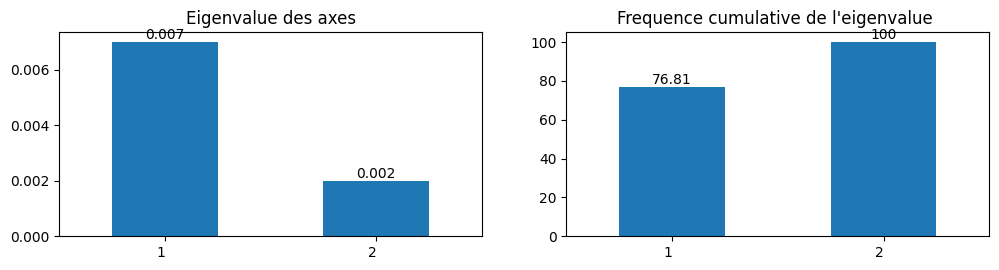

In [90]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

In [91]:
cal.dim_contributions(afc)

KeyError: "['col_contrib_dim3'] not in index"

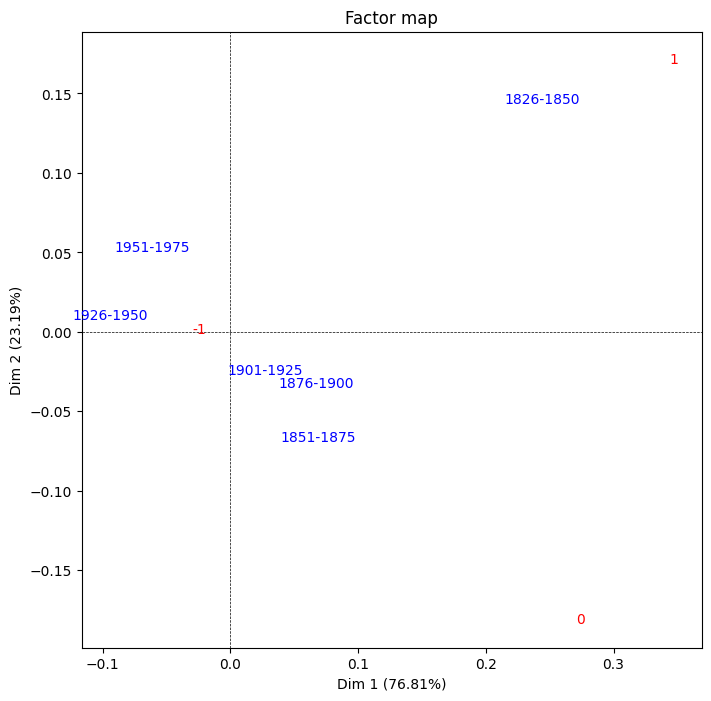

In [92]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

In [98]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=3,num_y_axis=4,figsize=(8,8))

IndexError: index 3 is out of bounds for axis 1 with size 2

<Figure size 800x800 with 0 Axes>

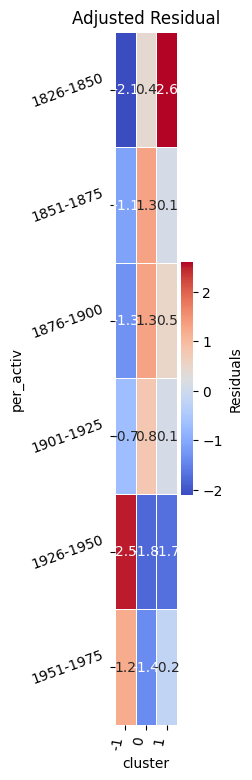

In [99]:
### Number of clusters
width= df['cluster'].max()
pp = bl.plot_chi2_residuals(observed.T, figsize=(width, 9))

In [101]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(pd.DataFrame(clu_prof_short[['Cluster_Size','number_centroid','number_f', 'prop_f']]))

,Cluster_Size,number_centroid,number_f,prop_f
0,1589,67,0,0.0
1,67,57,0,0.0
2,57,0,0,0.0


In [105]:
### write centroids to database table for more deep inspection
#db = '../../data/data_analysis.db'

#table_name='clusters_kmodes_centroids_c54'
#table_name='mca_kmeans_clusters_centroids'

#clu_prof_short['run']='cen16'
#clu_prof_short['run']='cen32'
#clu_prof_short['run']='cen64'


#conn = sql.connect(db)
# commented for safety, uncomment to execute
# clu_prof_short.to_sql(table_name, conn, if_exists='append', index=True)
#conn.close()


clu_prof_short['run']='cen32'
csv_path = '../da5_data/mca_kmeans_clusters_centroids.csv'
clu_prof_short.to_csv(csv_path, index=True)

In [106]:
pers_cluster=df_pm[['person_uri', 'cluster']]
pers_cluster.head()

,person_uri,cluster
0,http://www.wikidata.org/entity/Q204508,-1
1,http://www.wikidata.org/entity/Q529604,-1
2,http://www.wikidata.org/entity/Q567735,0
3,http://www.wikidata.org/entity/Q6166535,-1
4,http://www.wikidata.org/entity/Q3164481,-1


In [107]:
### write clusters to database table for more deep inspection
db = '../../data/data_analysis.db'

table_name='mca_kmeans_clusters'

# pers_cluster['run']='cen16'
pers_cluster['run']='cen32'
# pers_cluster['run']='cen64'

conn = sql.connect(db)
# cursor = conn.cursor()
pers_cluster.to_sql(table_name, conn, if_exists='append', index=True)
conn.close()

OperationalError: unable to open database file

## Plot clusters

In [108]:
categorical_cols = df_actives.columns.to_list()[:4]
print(categorical_cols)

['gender', 'country', 'occup_main', 'occup_sec']


In [109]:
df_actives.head(1)

,gender,country,occup_main,occup_sec,edpl,cluster
0,male,Central Europe,archaeologist,other,University of Göttingen,-1


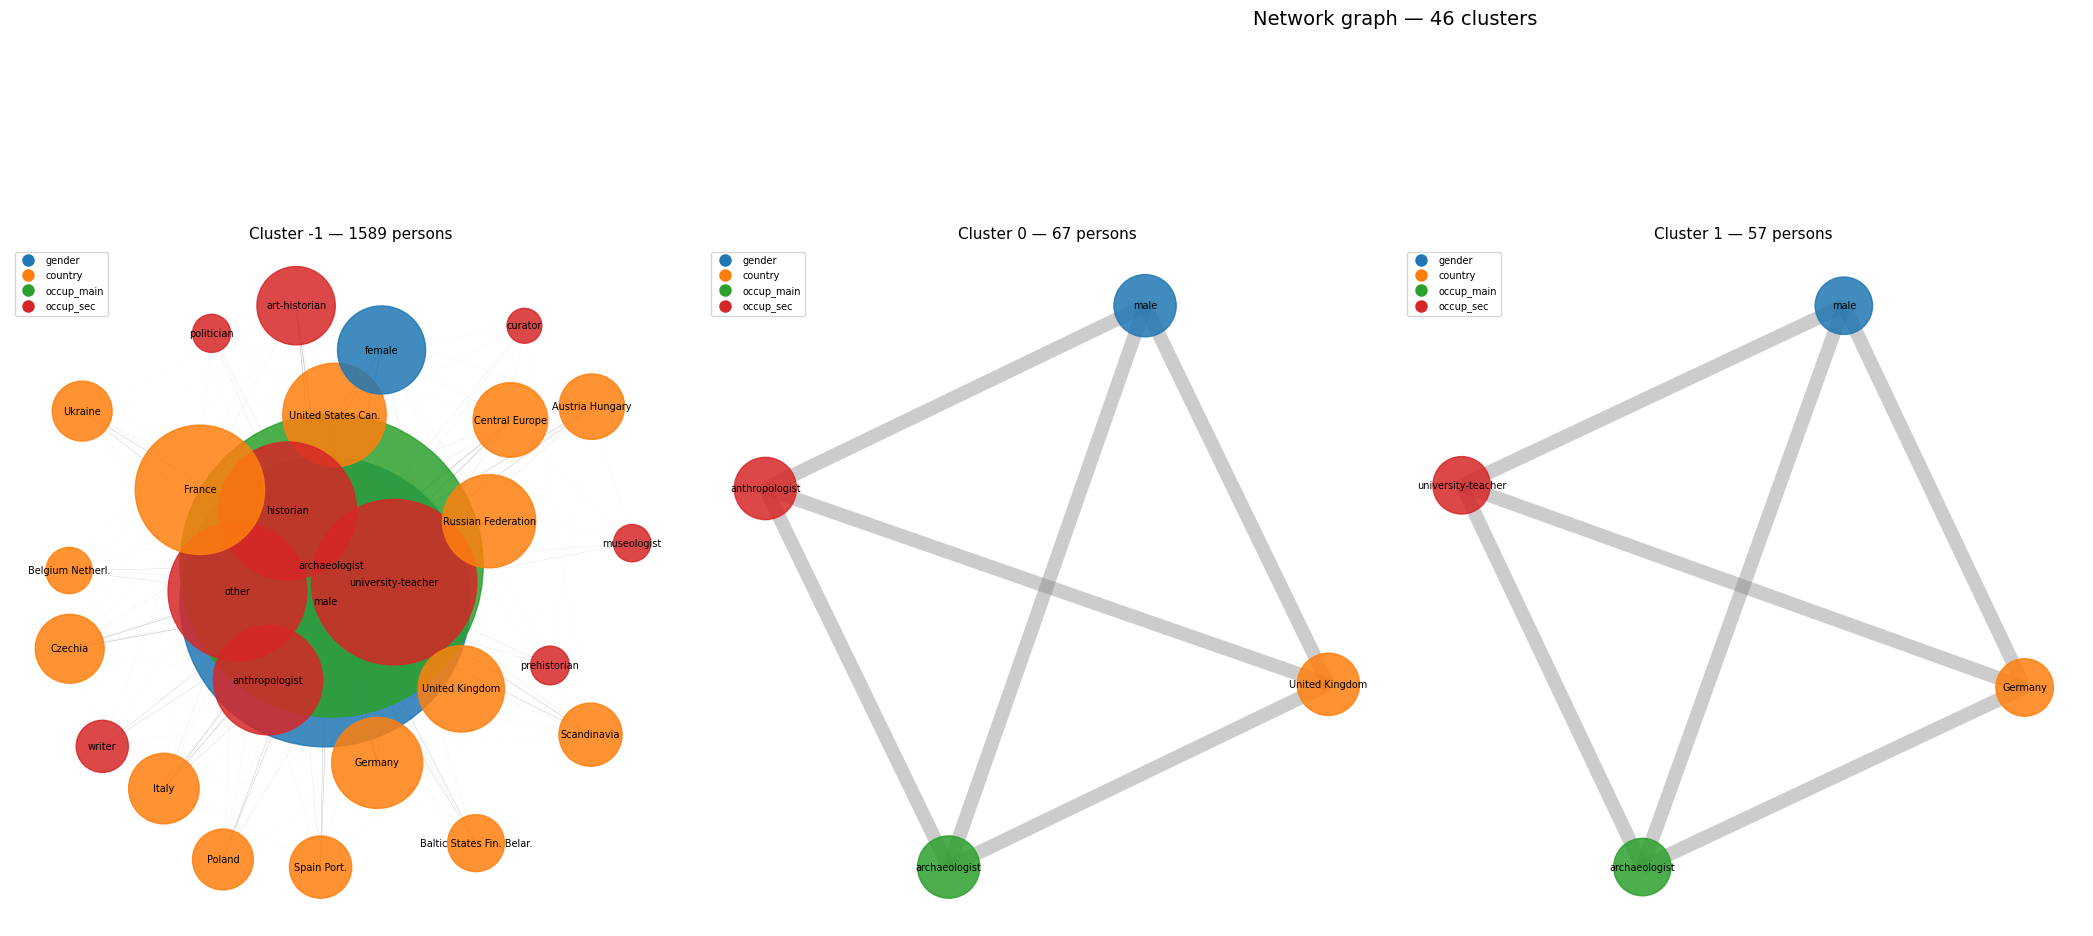

In [110]:
## ici on voit les attractions de modalités
# les variables au centre ou très liées structurent le cluster
pict_address='../images/kmeans_ACM_clusters_4_variables_32cl.png'
cf.plot_cluster_networks(df_actives, categorical_cols, 46, 
        pict_address=pict_address)

## Test clusters correspondence

In [111]:
conn = sql.connect(db)


# 2. Define your SQL query
query = """
SELECT mkc.person_uri, mkc.cluster cluster_kmean, kc.cluster cluster_kmode
from mca_kmeans_clusters mkc, kmodes_clusters kc 
where mkc.person_uri = kc.person_uri
and mkc.run = 'cen32'
and kc.run = 'cen32'
order by cluster_kmean, cluster_kmode
"""

# 3. Execute the query and load results into a DataFrame
dfq = pd.read_sql_query(query, conn)

# 4. Close the connection
conn.close()

# Display the first few rows
print(dfq.head())

OperationalError: unable to open database file

In [112]:
# 5. Validate against Generation (Unused Variable)
# Cross-tabulation : contingency_table
observed = pd.crosstab(dfq['cluster_kmode'], dfq['cluster_kmean'])


NameError: name 'dfq' is not defined

In [113]:
bl.check_chi_square_test_validity(observed)

Table valid for Chi-square test: True


In [114]:
expected=bl.bivariate_stats(observed)

Chi-square : 16.69 , dof : 10
p-value : 0.081
Inertia (Phi-square):  0.01
Cramer:  0.07


### CA

In [115]:
afc = fa.CA(row_labels=observed.index,col_labels=observed.columns)
afc.fit(observed.values)

,n_components,None
,row_labels,"Index([-1, 0,...ame='cluster')"
,col_labels,Index(['1826-...e='per_activ')
,stats,True


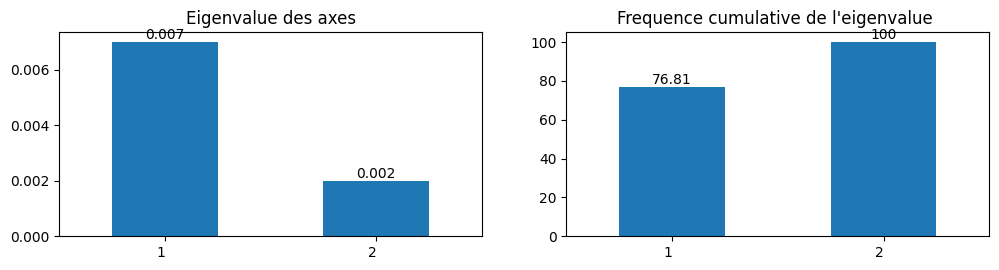

In [116]:
### Inertia (Phi-square - Eigenvalue):  0.108
cal.print_eigenvalue(afc)

In [117]:
cal.dim_contributions(afc)

KeyError: "['col_contrib_dim3'] not in index"

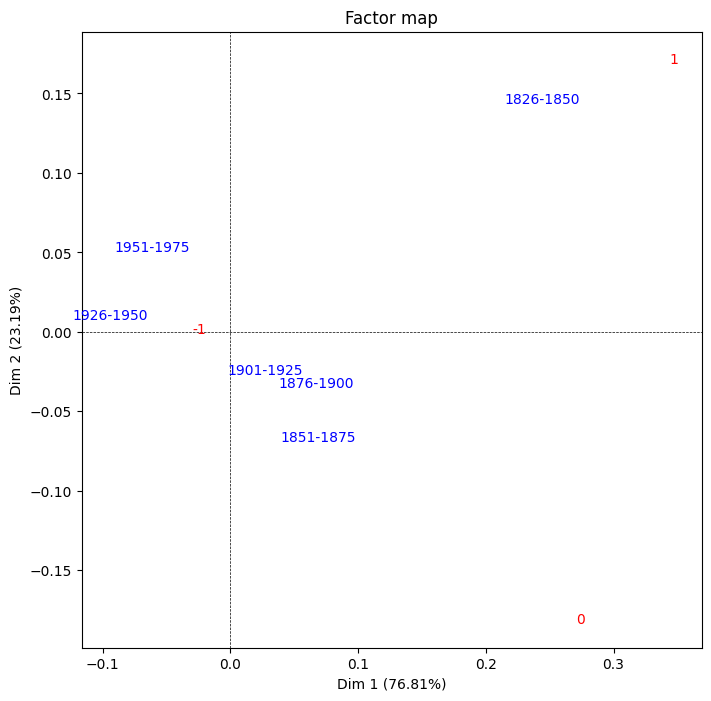

In [118]:
# Represent dimension 1 and 2
afc.mapping(num_x_axis=1,num_y_axis=2,figsize=(8,8))

In [119]:
# Represent dimension 2 and 3
afc.mapping(num_x_axis=3,num_y_axis=4,figsize=(8,8))

IndexError: index 2 is out of bounds for axis 1 with size 2

<Figure size 800x800 with 0 Axes>

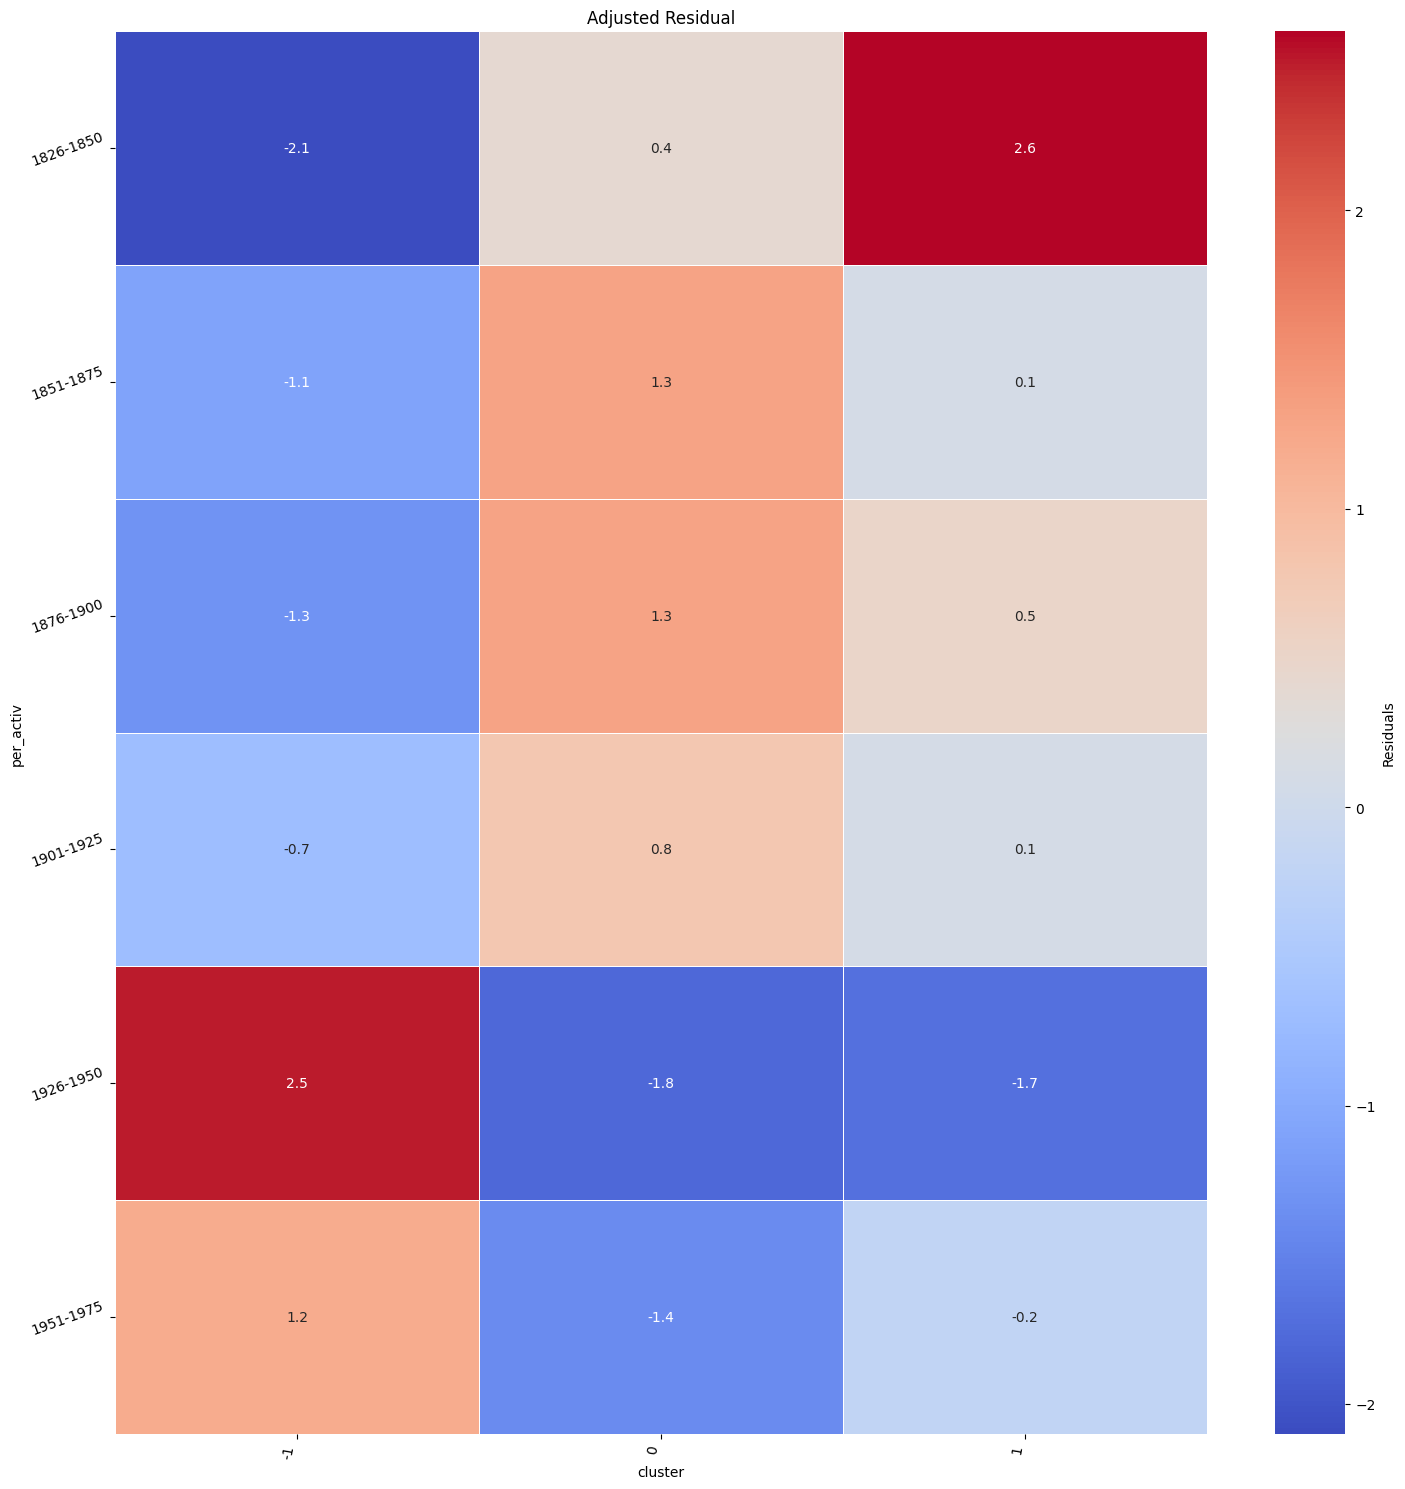

In [120]:
pp = bl.plot_chi2_residuals(observed.T, figsize=(15, 15))

In [121]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(pd.DataFrame(clu_prof_short[['label','number_in_cl','number_centroid','number_f', 'prop_f']]))

KeyError: "['label', 'number_in_cl'] not in index"